In [5]:
import pandas as pd
import numpy as np 


In [11]:
df = pd.read_csv('titanic_toy.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [17]:
print(df['Age'].isnull().sum()/len(df['Age'])*100)
print(df['Fare'].isnull().sum()/len(df['Fare'])*100)

19.865319865319865
5.05050505050505


In [25]:
# using the pandas fillna method to fill the missong values using the meand and median of the data 

df['Age_mean'] = df['Age'].fillna(df['Age'].mean())
df['Age_median'] = df['Age'].fillna(df['Age'].median())
df['Fare_mean'] = df['Fare'].fillna(df['Fare'].mean())
df['Fare_median'] = df['Fare'].fillna(df['Fare'].median())

df.head()


,Age,Fare,Family,Survived,Age_mean,Age_median,Fare_mean,Fare_median
0,22.0,7.2500,1,0,22.0,22.0,7.2500,7.2500
1,38.0,71.2833,1,1,38.0,38.0,71.2833,71.2833
2,26.0,7.9250,0,1,26.0,26.0,7.9250,7.9250
3,35.0,53.1000,1,1,35.0,35.0,53.1000,53.1000
4,35.0,8.0500,0,0,35.0,35.0,8.0500,8.0500


In [24]:
# now we wil find the variances to see if there is much difference between the mean and median imputed data and the original data
print(df['Age'].var())
print(df['Age_mean'].var())
print(df['Age_median'].var())


## there is difference in the variances but it is not much and the distribution of the data is also not much different so we can say that the data is missing at random and we can drop the data without much loss of information but we wont in this case as weare learning how to ahndle numerical data 

211.01912474630802
169.0523999372108
169.51249827942345


In [ ]:
print(df['Fare'].var())
print(df['Fare_mean'].var())
print(df['Fare_median'].var())
# not much difference int he variances of the fare col 

2530.6730768999514
2402.717696607258
2417.971599672527


In [ ]:
# now for stanard deviation 

print(df['Age'].std())
print(df['Age_mean'].std())
print(df['Age_median'].std())
# Almost same standard deviation for the age column

14.526497332334042
13.002015226002882
13.019696550973201


In [ ]:
print(df['Fare'].std())
print(df['Fare_mean'].std())
print(df['Fare_median'].std())
# same goes for here as well 

50.305795659147975
49.017524382686425
49.17287463299789


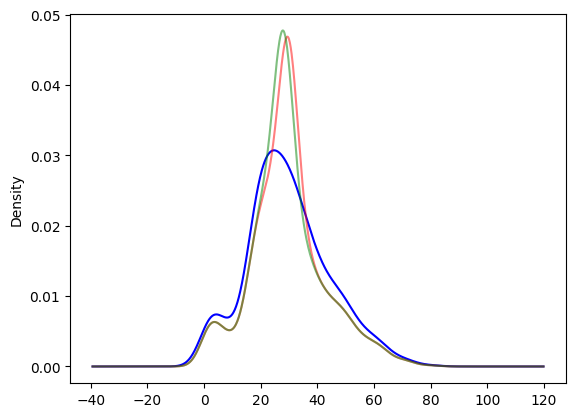

In [29]:
## now we will plot the distribution of the the age columns as it has the most variance difference 

import matplotlib.pyplot as plt

fig  = plt.figure()
ax = fig.add_subplot(111)
df['Age'].plot(kind = 'kde', ax =ax, color= 'blue')
df['Age_mean'].plot(kind = 'kde', ax =ax, color= 'red', alpha = 0.5)
df['Age_median'].plot(kind = 'kde', ax =ax, color= 'green', alpha= 0.5)

plt.show()

In [ ]:
# as we can why there a difference between the orignal and the imputed value for age

In [30]:
# Using sklearn to impute the missing values using Simple IMputer

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(df.drop('Survived', axis = 1), df['Survived'], test_size = 0.2, random_state = 42)

In [34]:
from sklearn.compose import ColumnTransformer

trf = ColumnTransformer(transformers=[
    ('impute_age', SimpleImputer(strategy='mean'), ['Age']),
    
])
trf.fit(x_train)
x_train_trf=trf.transform(x_train)
x_test_trf=trf.transform(x_test)

print(x_train_trf[5:10])
print()
print(x_test_trf[5:10])

[[24.        ]
 [45.        ]
 [29.        ]
 [29.49884615]
 [29.49884615]]

[[26.        ]
 [29.49884615]
 [16.        ]
 [16.        ]
 [19.        ]]


In [ ]:
# done #